In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Find the main project folder
cwd = Path(os.getcwd()).resolve()
PROJECT_ROOT = cwd if (cwd / "data").exists() else cwd.parent

# Main folders used in the project
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
TAB_DIR = PROJECT_ROOT / "reports" / "tables"

# Create output folders if they are missing
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("Project folders are ready")

# Save a chart and still show it in the notebook
def show_and_save(fig, name, dpi=200):
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {name}.png")
    plt.show()
    plt.close(fig)

# Save a dataframe as a CSV
def save_table(df, name):
    path = TAB_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"Saved table: {name}.csv")

Project folders are ready


In [2]:
# Load the two raw files
train_path = RAW_DIR / "train.csv"
store_path = RAW_DIR / "store.csv"

train = pd.read_csv(train_path, low_memory=False)
store = pd.read_csv(store_path)

# Quick look at the size and structure
print("Train shape:", train.shape)
print("Store shape:", store.shape)

print("\nTrain columns:")
print(train.columns.tolist())

print("\nStore columns:")
print(store.columns.tolist())

display(train.head())
display(store.head())

Train shape: (1017209, 9)
Store shape: (1115, 10)

Train columns:
['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']

Store columns:
['Store', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [3]:
# Check column types
print("Train data types:")
display(train.dtypes)

print("\nStore data types:")
display(store.dtypes)

# Check missing values
print("\nMissing values in train:")
display(train.isna().sum())

print("\nMissing values in store:")
display(store.isna().sum())

# Check for duplicate rows
print("\nDuplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in store:", store.duplicated().sum())

Train data types:


Store             int64
DayOfWeek         int64
Date             object
Sales             int64
Customers         int64
Open              int64
Promo             int64
StateHoliday     object
SchoolHoliday     int64
dtype: object


Store data types:


Store                          int64
StoreType                     object
Assortment                    object
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                 object
dtype: object


Missing values in train:


Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64


Missing values in store:


Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


Duplicate rows in train: 0
Duplicate rows in store: 0


In [4]:
# Check whether missing Promo2 details belong to stores without Promo2
print("Promo2 missing values by Promo2 status:")
display(
    store.groupby("Promo2")[
        ["Promo2SinceWeek", "Promo2SinceYear", "PromoInterval"]
    ].apply(lambda x: x.isna().sum())
)

# Look at stores with missing competition information
print("\nStores with missing competition details:")
display(
    store[
        store["CompetitionDistance"].isna()
        | store["CompetitionOpenSinceMonth"].isna()
        | store["CompetitionOpenSinceYear"].isna()
    ].head(20)
)

Promo2 missing values by Promo2 status:


,Promo2SinceWeek,Promo2SinceYear,PromoInterval
Promo2,,,
0,544,544,544
1,0,0,0



Stores with missing competition details:


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
11,12,a,c,1070.0,NaN,NaN,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
12,13,d,a,310.0,NaN,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov"
15,16,a,c,3270.0,NaN,NaN,0,NaN,NaN,NaN
18,19,a,c,3240.0,NaN,NaN,1,22.0,2011.0,"Mar,Jun,Sept,Dec"
21,22,a,a,1040.0,NaN,NaN,1,22.0,2012.0,"Jan,Apr,Jul,Oct"
25,26,d,a,2300.0,NaN,NaN,0,NaN,NaN,NaN
28,29,d,c,2170.0,NaN,NaN,0,NaN,NaN,NaN
31,32,a,a,2910.0,NaN,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov"
39,40,a,a,180.0,NaN,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov"
40,41,d,c,1180.0,NaN,NaN,1,31.0,2013.0,"Jan,Apr,Jul,Oct"


In [6]:
# Make a working copy
train_clean = train.copy()
store_clean = store.copy()

# Convert the date column
train_clean["Date"] = pd.to_datetime(train_clean["Date"])

# Fill Promo2 details for stores that never used Promo2
no_promo2 = store_clean["Promo2"] == 0

store_clean.loc[no_promo2, "Promo2SinceWeek"] = (
    store_clean.loc[no_promo2, "Promo2SinceWeek"].fillna(0)
)

store_clean.loc[no_promo2, "Promo2SinceYear"] = (
    store_clean.loc[no_promo2, "Promo2SinceYear"].fillna(0)
)

store_clean.loc[no_promo2, "PromoInterval"] = (
    store_clean.loc[no_promo2, "PromoInterval"].fillna("None")
)

# Add simple date columns that will be useful later
train_clean["Year"] = train_clean["Date"].dt.year
train_clean["Month"] = train_clean["Date"].dt.month
train_clean["Quarter"] = train_clean["Date"].dt.quarter

print("Train shape:", train_clean.shape)
print("Store shape:", store_clean.shape)

print("\nDate range:")
print(train_clean["Date"].min(), "to", train_clean["Date"].max())

print("\nRemaining missing values in store:")
display(store_clean.isna().sum())

Train shape: (1017209, 12)
Store shape: (1115, 10)

Date range:
2013-01-01 00:00:00 to 2015-07-31 00:00:00

Remaining missing values in store:


Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek                0
Promo2SinceYear                0
PromoInterval                  0
dtype: int64

In [7]:
# Add store details to each daily sales record
merged = train_clean.merge(
    store_clean,
    on="Store",
    how="left",
    validate="many_to_one"
)

print("Merged shape:", merged.shape)

# Check whether any store details failed to match
print("\nMissing StoreType after merge:", merged["StoreType"].isna().sum())

display(merged.head())

Merged shape: (1017209, 21)

Missing StoreType after merge: 0


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,...,Quarter,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,...,3,c,a,1270.0,9.0,2008.0,0,0.0,0.0,None
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,...,3,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,...,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,...,3,c,c,620.0,9.0,2009.0,0,0.0,0.0,None
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,...,3,a,a,29910.0,4.0,2015.0,0,0.0,0.0,None


In [8]:
# Check sales when stores were open or closed
print("Rows by store status:")
display(merged["Open"].value_counts())

print("\nClosed stores with sales:")
print(merged[(merged["Open"] == 0) & (merged["Sales"] > 0)].shape[0])

print("\nOpen stores with zero sales:")
print(merged[(merged["Open"] == 1) & (merged["Sales"] == 0)].shape[0])

# Check the range of sales and customer numbers
print("\nSales range:", merged["Sales"].min(), "to", merged["Sales"].max())
print("Customer range:", merged["Customers"].min(), "to", merged["Customers"].max())

Rows by store status:


Open
1    844392
0    172817
Name: count, dtype: int64


Closed stores with sales:
0

Open stores with zero sales:
54

Sales range: 0 to 41551
Customer range: 0 to 7388


In [9]:
# Look at open stores that recorded no sales
zero_sales_open = merged[
    (merged["Open"] == 1) &
    (merged["Sales"] == 0)
]

print("Open stores with zero sales:", len(zero_sales_open))

display(
    zero_sales_open[
        [
            "Store",
            "Date",
            "Sales",
            "Customers",
            "Promo",
            "StateHoliday",
            "SchoolHoliday"
        ]
    ].head(20)
)

Open stores with zero sales: 54


,Store,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday
86825,971,2015-05-15,0,0,0,0,1
142278,674,2015-03-26,0,0,0,0,0
196938,699,2015-02-05,0,0,1,0,0
322053,708,2014-10-01,0,0,1,0,0
330176,357,2014-09-22,0,0,0,0,0
340348,227,2014-09-11,0,0,0,0,0
340860,835,2014-09-11,0,0,0,0,0
341795,835,2014-09-10,0,0,0,0,0
346232,548,2014-09-05,0,0,1,0,1
346734,28,2014-09-04,0,0,1,0,0


In [11]:
# Keep the merged data as our main analysis dataset
analysis_data = merged.copy()

# Save cleaned files for later use
train_clean.to_csv(PROCESSED_DIR / "train_clean.csv", index=False)
store_clean.to_csv(PROCESSED_DIR / "store_clean.csv", index=False)
analysis_data.to_csv(PROCESSED_DIR / "retail_analysis_data.csv", index=False)

print("Saved:")
print("train_clean.csv")
print("store_clean.csv")
print("retail_analysis_data.csv")

Saved:
train_clean.csv
store_clean.csv
retail_analysis_data.csv


In [12]:
# Add a month column so we can track sales over time
analysis_data["YearMonth"] = analysis_data["Date"].dt.to_period("M").astype(str)

# Total sales by month
monthly_sales = (
    analysis_data.groupby("YearMonth", as_index=False)["Sales"]
    .sum()
)

display(monthly_sales.head())
display(monthly_sales.tail())

,YearMonth,Sales
0,2013-01,180132207
1,2013-02,171534275
2,2013-03,201180369
3,2013-04,183431432
4,2013-05,185411063


,YearMonth,Sales
26,2015-03,205631683
27,2015-04,197918886
28,2015-05,189143897
29,2015-06,207363373
30,2015-07,212322616


Saved figure: monthly_sales_over_time.png


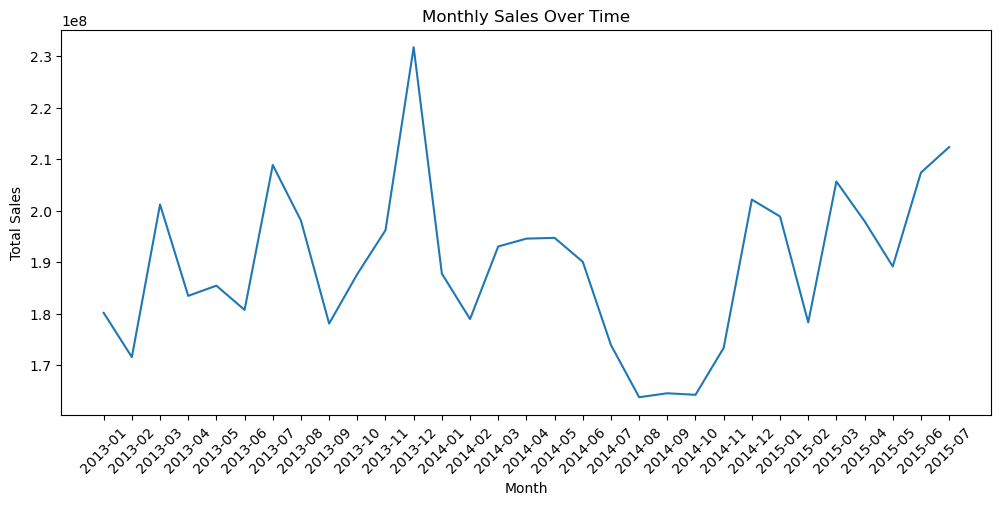

In [13]:
# Plot total sales by month
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(monthly_sales["YearMonth"], monthly_sales["Sales"])

ax.set_title("Monthly Sales Over Time")
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales")

plt.xticks(rotation=45)

show_and_save(fig, "monthly_sales_over_time")

In [14]:
# Compare sales on promotion days and normal days
promo_sales = (
    analysis_data[analysis_data["Open"] == 1]
    .groupby("Promo", as_index=False)
    .agg(
        AverageSales=("Sales", "mean"),
        AverageCustomers=("Customers", "mean")
    )
)

display(promo_sales)

,Promo,AverageSales,AverageCustomers
0,0,5929.407603,696.856886
1,1,8228.281239,844.434401


Saved figure: average_sales_promo_vs_no_promo.png


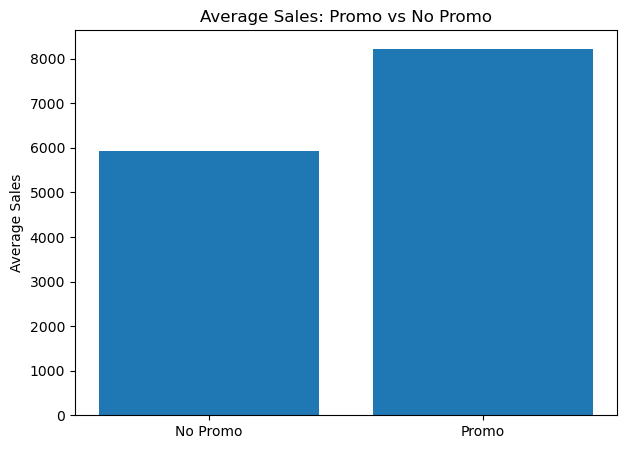

In [15]:
# Compare average sales on promo and non-promo days
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    ["No Promo", "Promo"],
    promo_sales["AverageSales"]
)

ax.set_title("Average Sales: Promo vs No Promo")
ax.set_ylabel("Average Sales")

show_and_save(fig, "average_sales_promo_vs_no_promo")

In [16]:
# Compare performance across store types
store_type_sales = (
    analysis_data[analysis_data["Open"] == 1]
    .groupby("StoreType", as_index=False)
    .agg(
        AverageSales=("Sales", "mean"),
        AverageCustomers=("Customers", "mean")
    )
    .sort_values("AverageSales", ascending=False)
)

display(store_type_sales)

,StoreType,AverageSales,AverageCustomers
1,b,10231.407505,2021.822335
2,c,6932.512755,815.465887
0,a,6925.167661,795.361469
3,d,6822.141881,606.339876


Saved figure: average_sales_by_store_type.png


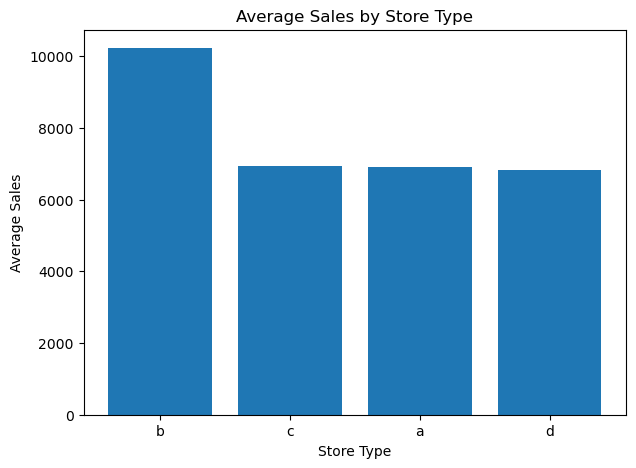

In [17]:
# Show average sales by store type
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    store_type_sales["StoreType"],
    store_type_sales["AverageSales"]
)

ax.set_title("Average Sales by Store Type")
ax.set_xlabel("Store Type")
ax.set_ylabel("Average Sales")

show_and_save(fig, "average_sales_by_store_type")

In [18]:
# Compare average sales for each store
store_performance = (
    analysis_data[analysis_data["Open"] == 1]
    .groupby("Store", as_index=False)
    .agg(
        AverageSales=("Sales", "mean"),
        AverageCustomers=("Customers", "mean")
    )
)

top_stores = store_performance.sort_values("AverageSales", ascending=False).head(10)
bottom_stores = store_performance.sort_values("AverageSales").head(10)

print("Top 10 stores:")
display(top_stores)

print("\nBottom 10 stores:")
display(bottom_stores)

Top 10 stores:


,Store,AverageSales,AverageCustomers
816,817,21757.483418,3130.573980
261,262,20718.515924,3402.010616
1113,1114,20666.562500,3200.946429
250,251,19123.068036,2450.492940
841,842,18574.795820,1149.242765
512,513,18179.089286,2096.335459
561,562,17969.556263,3105.053079
787,788,17961.914541,1717.901786
382,383,17294.716667,2205.447436
755,756,16574.816431,2346.572529



Bottom 10 stores:


,Store,AverageSales,AverageCustomers
306,307,2703.736573,307.805627
542,543,2790.380282,240.183099
197,198,2900.604859,338.478261
207,208,2936.290816,413.471939
840,841,2972.608974,412.173077
253,254,3005.983312,258.673941
793,794,3083.812821,521.829487
218,219,3133.712452,406.444159
209,210,3193.984596,326.259307
424,425,3237.659794,434.381443


In [19]:
# Compare store details for the best and worst performers
top_store_details = store_clean[
    store_clean["Store"].isin(top_stores["Store"])
].copy()

bottom_store_details = store_clean[
    store_clean["Store"].isin(bottom_stores["Store"])
].copy()

print("Top store details:")
display(top_store_details.sort_values("Store"))

print("\nBottom store details:")
display(bottom_store_details.sort_values("Store"))

Top store details:


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
250,251,a,c,340.0,NaN,NaN,0,0.0,0.0,None
261,262,b,a,1180.0,5.0,2013.0,0,0.0,0.0,None
382,383,a,c,350.0,NaN,NaN,0,0.0,0.0,None
512,513,a,a,400.0,8.0,2013.0,0,0.0,0.0,None
561,562,b,c,1210.0,NaN,NaN,0,0.0,0.0,None
755,756,a,c,50.0,NaN,NaN,1,40.0,2011.0,"Jan,Apr,Jul,Oct"
787,788,a,c,1530.0,3.0,2013.0,0,0.0,0.0,None
816,817,a,a,140.0,3.0,2006.0,0,0.0,0.0,None
841,842,d,c,1200.0,11.0,2007.0,0,0.0,0.0,None
1113,1114,a,c,870.0,NaN,NaN,0,0.0,0.0,None



Bottom store details:


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
197,198,a,a,290.0,9.0,2002.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
207,208,c,a,300.0,4.0,2006.0,0,0.0,0.0,None
209,210,d,a,970.0,11.0,1999.0,1,5.0,2013.0,"Feb,May,Aug,Nov"
218,219,a,a,1640.0,2.0,2013.0,0,0.0,0.0,None
253,254,d,a,330.0,3.0,2008.0,1,1.0,2012.0,"Mar,Jun,Sept,Dec"
306,307,a,a,18660.0,9.0,2002.0,0,0.0,0.0,None
424,425,d,c,1460.0,NaN,NaN,0,0.0,0.0,None
542,543,c,a,1080.0,12.0,2012.0,0,0.0,0.0,None
793,794,c,c,5090.0,9.0,2006.0,0,0.0,0.0,None
840,841,a,a,27650.0,8.0,2004.0,0,0.0,0.0,None


In [20]:
# Add store details to the performance table
store_performance_full = store_performance.merge(
    store_clean[
        [
            "Store",
            "StoreType",
            "Assortment",
            "CompetitionDistance",
            "Promo2"
        ]
    ],
    on="Store",
    how="left"
)

# Compare average store performance by assortment
assortment_performance = (
    store_performance_full
    .groupby("Assortment", as_index=False)
    .agg(
        AverageSales=("AverageSales", "mean"),
        AverageCustomers=("AverageCustomers", "mean"),
        NumberOfStores=("Store", "count")
    )
    .sort_values("AverageSales", ascending=False)
)

display(assortment_performance)

,Assortment,AverageSales,AverageCustomers,NumberOfStores
1,b,8555.417729,2045.332255,9
2,c,7295.765945,747.707590,513
0,a,6596.822481,740.804119,593


In [21]:
# Check whether nearby competition is linked to store performance
competition_check = store_performance_full[
    store_performance_full["CompetitionDistance"].notna()
]

correlation = competition_check["CompetitionDistance"].corr(
    competition_check["AverageSales"]
)

print("Correlation between competition distance and average sales:")
print(round(correlation, 3))

Correlation between competition distance and average sales:
-0.042


In [22]:
# Compare stores that use Promo2 with stores that do not
promo2_performance = (
    store_performance_full
    .groupby("Promo2", as_index=False)
    .agg(
        AverageSales=("AverageSales", "mean"),
        AverageCustomers=("AverageCustomers", "mean"),
        NumberOfStores=("Store", "count")
    )
)

display(promo2_performance)

,Promo2,AverageSales,AverageCustomers,NumberOfStores
0,0,7337.391682,836.808934,544
1,1,6550.089921,676.102917,571


In [23]:
# Compare sales across the days of the week
day_performance = (
    analysis_data[analysis_data["Open"] == 1]
    .groupby("DayOfWeek", as_index=False)
    .agg(
        AverageSales=("Sales", "mean"),
        AverageCustomers=("Customers", "mean")
    )
)

day_names = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}

day_performance["Day"] = day_performance["DayOfWeek"].map(day_names)

display(day_performance)

,DayOfWeek,AverageSales,AverageCustomers,Day
0,1,8216.073074,855.444984,Monday
1,2,7088.113656,769.986753,Tuesday
2,3,6728.122978,740.598876,Wednesday
3,4,6767.310159,755.569784,Thursday
4,5,7072.677012,781.771639,Friday
5,6,5874.840238,660.177526,Saturday
6,7,8224.723908,1441.532424,Sunday


Saved figure: average_sales_by_day.png


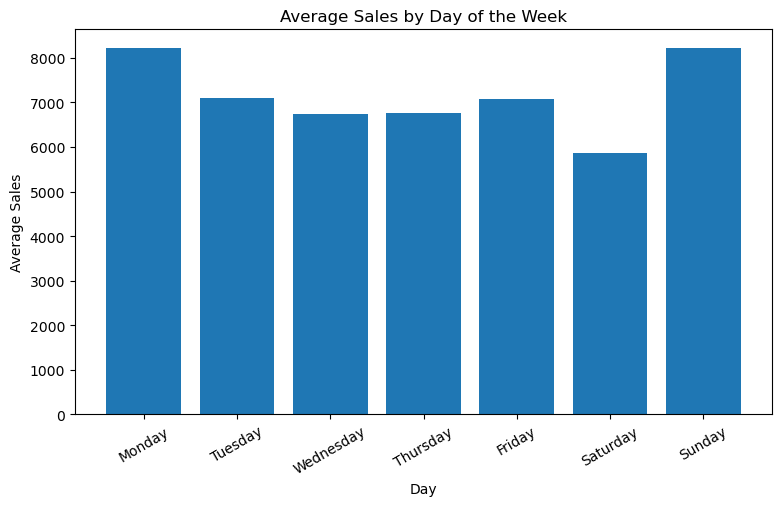

In [24]:
# Show average sales by day of the week
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    day_performance["Day"],
    day_performance["AverageSales"]
)

ax.set_title("Average Sales by Day of the Week")
ax.set_xlabel("Day")
ax.set_ylabel("Average Sales")

plt.xticks(rotation=30)

show_and_save(fig, "average_sales_by_day")

In [25]:
# Compare average sales by month
month_performance = (
    analysis_data[analysis_data["Open"] == 1]
    .groupby("Month", as_index=False)
    .agg(
        AverageSales=("Sales", "mean"),
        AverageCustomers=("Customers", "mean")
    )
)

month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

month_performance["MonthName"] = month_performance["Month"].map(month_names)

display(month_performance)

,Month,AverageSales,AverageCustomers,MonthName
0,1,6563.690444,722.514749,Jan
1,2,6589.165535,731.504792,Feb
2,3,6976.412026,759.081600,Mar
3,4,7046.228420,774.271806,Apr
4,5,7106.453154,779.290214,May
5,6,7000.978190,759.277357,Jun
6,7,6952.682125,752.745522,Jul
7,8,6648.984654,750.384706,Aug
8,9,6546.343035,745.613988,Sep
9,10,6602.843354,752.573557,Oct


Saved figure: average_sales_by_month.png


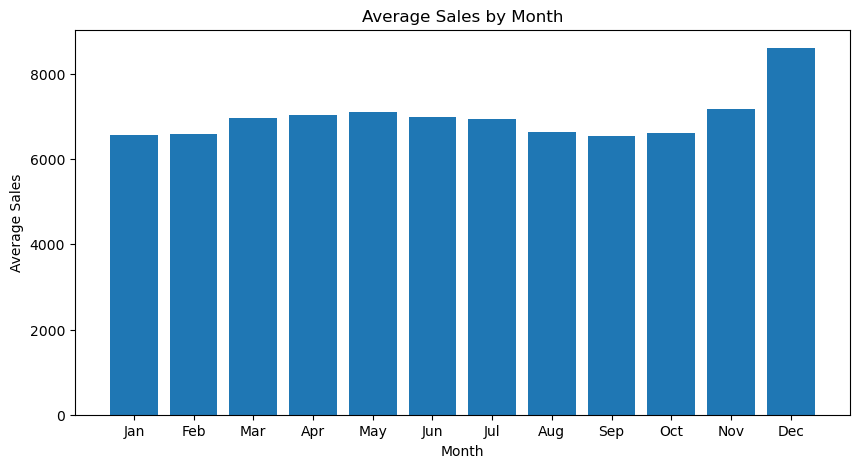

In [26]:
# Show average sales by month
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    month_performance["MonthName"],
    month_performance["AverageSales"]
)

ax.set_title("Average Sales by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Average Sales")

show_and_save(fig, "average_sales_by_month")

In [27]:
# Work out average sales per customer
customer_spend = analysis_data[
    (analysis_data["Open"] == 1) &
    (analysis_data["Customers"] > 0)
].copy()

customer_spend["SalesPerCustomer"] = (
    customer_spend["Sales"] / customer_spend["Customers"]
)

print("Overall average sales per customer:")
print(round(customer_spend["SalesPerCustomer"].mean(), 2))

Overall average sales per customer:
9.49


In [28]:
# Compare sales per customer across store types
spend_by_store_type = (
    customer_spend
    .groupby("StoreType", as_index=False)
    .agg(
        AverageSalesPerCustomer=("SalesPerCustomer", "mean")
    )
    .sort_values("AverageSalesPerCustomer", ascending=False)
)

display(spend_by_store_type)

,StoreType,AverageSalesPerCustomer
3,d,11.277862
0,a,8.846277
2,c,8.626227
1,b,5.133097


In [29]:
# See whether promotions affect spend per customer
promo_customer_spend = (
    customer_spend
    .groupby("Promo", as_index=False)
    .agg(
        AverageSalesPerCustomer=("SalesPerCustomer", "mean")
    )
)

display(promo_customer_spend)

,Promo,AverageSalesPerCustomer
0,0,8.941128
1,1,10.178907


In [30]:
# Save the main analysis tables
save_table(monthly_sales, "monthly_sales")
save_table(promo_sales, "promo_sales")
save_table(store_type_sales, "store_type_sales")
save_table(store_performance, "store_performance")
save_table(assortment_performance, "assortment_performance")
save_table(promo2_performance, "promo2_performance")
save_table(day_performance, "day_performance")
save_table(month_performance, "month_performance")
save_table(spend_by_store_type, "spend_by_store_type")
save_table(promo_customer_spend, "promo_customer_spend")

print("Analysis tables saved")

Saved table: monthly_sales.csv
Saved table: promo_sales.csv
Saved table: store_type_sales.csv
Saved table: store_performance.csv
Saved table: assortment_performance.csv
Saved table: promo2_performance.csv
Saved table: day_performance.csv
Saved table: month_performance.csv
Saved table: spend_by_store_type.csv
Saved table: promo_customer_spend.csv
Analysis tables saved
